### Imports

In [17]:
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import csv
import json
import argparse
from sklearn.metrics import accuracy_score
import graphviz
from sklearn.tree import export_graphviz
from imblearn.over_sampling import SMOTE
from sklearn import tree
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

import pickle
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.metrics import classification_report
pd.options.mode.chained_assignment = None
from sklearn.metrics import confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Definitions

In [2]:
class_numbers = ['facebook', 'instagram', 'linkedin', 'spotify', 'tiktok', 'twitter', 'wikipedia', 'youtube']
features_t = ['Min differential Packet Length', 'Max differential Packet Length', 'IAT min', 'IAT max', 'Packet Length Total', 'Min Packet Length', 'Max Packet Length', 'Flow Duration']

In [3]:
# Function to get scores of the model under test
def get_scores(classes, depth, n_tree, feats, max_leaf, X_train, y_train, X_test, y_test):

    model = RandomForestClassifier(max_depth=depth, n_estimators = n_tree, max_leaf_nodes=max_leaf, n_jobs=4,
                                    random_state=42, bootstrap=False, class_weight='balanced')
    model.fit(X_train[features], y_train)
    y_pred = model.predict(X_test[features])
    class_report = classification_report(y_test, y_pred, target_names=class_numbers, output_dict = True)
    macro_score = class_report['macro avg']['f1-score']
    weighted_score = class_report['weighted avg']['f1-score']

    return model, class_report, macro_score, weighted_score, y_pred

# Function to save final model for later analysis
def save_model(model, filename):
    pickle.dump(model, open(filename, 'wb'))

# Function to separate data into features and labels
def extract_x_y(Dataset, classes, features):
    Dataset = Dataset[Dataset["Label"].isin(class_numbers)]
    X = Dataset[features]
    y = Dataset['Label'].replace(class_numbers, range(len(class_numbers)))
    return X, y

# Function to Fit model based on optimal values of depth and number of estimators and use it
# to compute feature importance for all the features.
def get_feature_importance(depth, n_tree, max_leaf, X_train, y_train):
    rf_opt = RandomForestClassifier(max_depth = depth, n_estimators = n_tree,
                                    max_leaf_nodes=max_leaf, random_state=42, bootstrap=False, class_weight='balanced')
    rf_opt.fit(X_train, y_train)
    feature_importance = pd.DataFrame(rf_opt.feature_importances_)
    feature_importance.index = X_train.columns
    feature_importance = feature_importance.sort_values(by=list(feature_importance.columns),axis=0,ascending=False)

    return feature_importance

# Function to Fit model based on optimal values of depth and number of estimators and feature importance
# to find the fewest possible features to exceed the previously attained score with all selected features
def get_fewest_features(importance):
    sorted_feature_names = importance.index
    features = []
    for f in range(1,len(sorted_feature_names)+1):
        features.append(sorted_feature_names[0:f])
    return features

# Function to analyze different combinations of model hyperparameters
def analyze_models(class_numbers, model_type, depths, n_trees, X_train, y_train, X_test, y_test, max_leaf, filename_out):
    # Create a list to hold the results
    results = []

    if model_type == 'RF':
        # FOR EACH (depth, n_tree, feat)
        for depth in depths:
            for n_tree in n_trees:
                # get feature orders to use
                importance = get_feature_importance(depth, n_tree, max_leaf, X_train, y_train)
                print(importance)
                plt.figure(figsize=(10, 6))
                plt.barh(importance.index, importance[0])
                plt.gca().invert_yaxis()
                plt.title("Feature Importance in Random Forest")
                plt.xlabel("Importance Score")
                plt.ylabel("Feature")
                plt.tight_layout()
                plt.show()
                m_feats = get_fewest_features(importance)
                for feats in m_feats:
                    # Get the scores with the given (depth, n_tree, feat)
                    model, c_report, macro_f1, weight_f1, y_pred = get_scores(
                        class_numbers, depth, n_tree, feats, max_leaf, X_train, y_train, X_test, y_test
                    )

                    # Append results as a dictionary
                    results.append({
                        "depth": depth,
                        "n_tree": n_tree,
                        "max_leaf": max_leaf,
                        "n_feat": len(feats),
                        "macro": macro_f1,
                        "weighted": weight_f1,
                        "features": list(feats),  # Convert features to a list
                        "c_report": c_report  # Add the classification report
                    })

    # Write the results to a .json file
    with open(filename_out, mode="w") as file:
        json.dump(results, file, indent=4)  # Pretty-print JSON with an indentation of 4 spaces

    print("Analysis Complete. Check output file.")
    return []

def find_best_parameters(json_file, metric="weighted"):
    # Load the JSON file
    with open(json_file, 'r') as file:
        data = json.load(file)

    # Check if data is empty
    if not data:
        print("The JSON file is empty!")
        return None

    # Find the best configuration based on the specified metric
    best_config = max(data, key=lambda x: x[metric])

    # Print summary including depth
    print("Best Configuration:")
    print(f"Depth: {best_config['depth']}")
    print(f"N_tree: {best_config['n_tree']}")
    print(f"Max_leaf: {best_config['max_leaf']}")
    print(f"Number of Features: {best_config['n_feat']}")
    print(f"{metric.capitalize()} F1 Score: {best_config[metric]}")
    print(f"Features: {best_config['features']}")
    print(f"Classification Report: {best_config['c_report']}")

    return best_config

def evaluate_model_overfitting(model, X_train, y_train, X_test, y_test):
    # Evaluate training performance
    y_train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_report = classification_report(y_train, y_train_pred, output_dict=True)

    # Evaluate test performance
    y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_report = classification_report(y_test, y_test_pred, output_dict=True)

    # Analyze performance difference
    performance_diff = train_accuracy - test_accuracy
    if performance_diff > 0.1:  # Large gap between train and test
        evaluation = "The model is likely overfitting. Try regularization or simplifying the model."
    elif train_accuracy < 0.6 and test_accuracy < 0.6:  # Both low accuracies
        evaluation = "The model is likely underfitting. Try increasing complexity or adding more features."
    else:
        evaluation = "The model has a good balance between training and testing performance."

    # Print and return results
    results = {
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Train Report": train_report,
        "Test Report": test_report,
        "Evaluation": evaluation
    }

    print(f"Train Accuracy: {train_accuracy}")
    print(f"Test Accuracy: {test_accuracy}")
    print(f"Performance Difference: {performance_diff}")
    print(f"Evaluation: {evaluation}")

    return results

# --- Plot Confusion Matrix as a Heatmap ---

def plot_confusion_matrix(conf_matrix, labels, save_path="confusion_matrix.png"):
    labels = ['facebook', 'instagram', 'linkedin', 'spotify', 'tiktok', 'twitter', 'wikipedia', 'youtube']

    # Scale accuracy values to percentages
    conf_matrix = np.round(conf_matrix * 100, 2)

    plt.figure(figsize=(12, 10))
    plt.rcParams["font.family"] = "Quattrocento Sans"

    heatmap = sns.heatmap(
        conf_matrix,
        annot=True,
        fmt=".0f",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        annot_kws={'size': 22}
    )

    plt.xlabel("Predicted (Classes)", fontsize=22)
    plt.ylabel("Actual (Classes)", fontsize=22)

    # Set tick label font sizes and align x labels to center under ticks
    plt.xticks(rotation=30, ha='center', fontsize=22)
    plt.yticks(rotation=0, fontsize=22)

    # Colorbar customization
    colorbar = heatmap.collections[0].colorbar
    colorbar.set_ticks([0, 20, 40, 60, 80, 100])
    colorbar.set_ticklabels(["0", "20", "40", "60", "80", "100"])
    colorbar.ax.tick_params(labelsize=22)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_metrics_bar_chart(accuracy, precision, recall, weighted_f1, macro_f1, save_path="metrics_plot.png"):
    metrics = ["Accuracy", "Precision", "Recall", "Weighted F1", "Macro F1"]
    scores = [accuracy, precision, recall, weighted_f1, macro_f1]

    font_size = 44  # Set the desired font size for all elements

    plt.figure(figsize=(24, 12))  # Increase width for better spacing
    bars = plt.bar(metrics, scores, color=["navy", "darkblue", "royalblue", "steelblue", "skyblue"])
    plt.ylim(60, 100)

    # Adding text annotations with specified font properties
    for bar, score in zip(bars, scores):
        plt.text(bar.get_x() + bar.get_width()/2, score + 1, f"{score:.1f}",
                 ha="center", fontsize=font_size, fontfamily="Quattrocento Sans")

    # Apply font size to axis labels, title, and ticks
    plt.ylabel("Score [%]", fontsize=font_size, fontfamily="Quattrocento Sans")
    plt.xticks(fontsize=font_size, fontfamily="Quattrocento Sans")  # Rotate for spacing
    plt.yticks(fontsize=font_size, fontfamily="Quattrocento Sans")
    plt.title("Model Performance Metrics", fontsize=font_size, fontfamily="Quattrocento Sans")

    # Save the image
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# Define ANSI escape code for #8F493F (approximate as a terminal color)
COLOR_CODE = "\033[38;2;143;73;63m"  # RGB escape sequence for the desired color
RESET_CODE = "\033[0m"  # Reset color

# --- Function to Compute TP, TN, FP, FN for Each Class ---
def compute_per_class_metrics(y_true, y_pred):
    conf_matrix = confusion_matrix(y_true, y_pred)
    num_classes = conf_matrix.shape[0]  # Number of classes
    TP = np.diag(conf_matrix)  # True Positives
    FP = conf_matrix.sum(axis=0) - TP  # False Positives
    FN = conf_matrix.sum(axis=1) - TP  # False Negatives
    TN = conf_matrix.sum() - (FP + FN + TP)  # True Negatives

    return TP, TN, FP, FN

# --- Function to Display Per-Class Metrics with Color ---
def display_per_class_metrics(y_true, y_pred):
    labels = sorted(np.unique(y_true))  # Extract unique class labels
    TP, TN, FP, FN = compute_per_class_metrics(y_true, y_pred)

    print(f"\n{COLOR_CODE}=== Per-Class Confusion Metrics ==={RESET_CODE}")
    for i, label in enumerate(labels):
        print(f"{COLOR_CODE}Class {label}:{RESET_CODE}")
        print(f"{COLOR_CODE}  - TP: {TP[i]}, TN: {TN[i]}, FP: {FP[i]}, FN: {FN[i]}{RESET_CODE}")
        print(f"{COLOR_CODE}" + "-" * 40 + f"{RESET_CODE}")

# --- Function to Plot the Confusion Matrix for Each Class ---
def plot_per_class_metrics(y_true, y_pred):
    labels = sorted(np.unique(y_true))  # Extract unique class labels
    TP, TN, FP, FN = compute_per_class_metrics(y_true, y_pred)

    # Create subplots for each class
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))  # Adjust layout for 6 classes

    for idx, ax in enumerate(axes.flat):
        if idx >= len(labels):
            ax.axis("off")  # Hide extra subplots if classes are less than 6
            continue

        # Confusion Matrix for the class
        matrix = np.array([[f"TP\n{TP[idx]}", f"FP\n{FP[idx]}"],
                           [f"FN\n{FN[idx]}", f"TN\n{TN[idx]}"]])
        colors = np.array([[0, 1], [1, 0]])  # Blue for TP & TN, White for FP & FN

        # Heatmap with custom font properties
        sns.heatmap(colors, annot=matrix, fmt='', cmap="Blues", cbar=False,
                    xticklabels=["+", "-"], yticklabels=["+", "-"],
                    annot_kws={'size': 45, 'fontfamily': 'Quattrocento Sans'}, ax=ax)

        ax.set_xlabel("Actual Class", fontsize=40, fontname="Quattrocento Sans")
        ax.set_ylabel("Predicted Class", fontsize=40, fontname="Quattrocento Sans")
        ax.set_title(f"Class {labels[idx]}", fontsize=40, fontname="Quattrocento Sans")

    plt.tight_layout()
    plt.savefig("per_class_confusion_matrices.png", dpi=300, bbox_inches="tight")  # Save figure
    plt.show()


In [4]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


### Load input data

In [5]:
# train_data  = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/train_nims_app_1.csv")
train_data  = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/train_chalmers.csv")

# class_numbers = ['discord', 'messenger', 'signal', 'teams', 'telegram', 'whatsapp']
train_data = train_data[train_data['Label'].isin(class_numbers)]
train_data.describe()

,Min Packet Length,Max Packet Length,Packet Length Total,Packet Length Range,First4Sum,Last4Sum,Min differential Packet Length,Max differential Packet Length,IAT min,IAT max,IAT range,Flow Duration
count,2677.000000,2677.000000,2677.000000,2677.000000,2677.000000,2677.000000,2677.000000,2677.000000,2.677000e+03,2.677000e+03,2.677000e+03,2.677000e+03
mean,112.989541,1089.316025,3901.311169,976.326485,1766.651476,2134.659694,1.899141,968.997759,4.533545e+04,4.603139e+05,4.149785e+05,8.806809e+05
std,118.750064,434.082741,2491.803204,442.612692,1431.621605,1580.426775,10.151556,442.090625,1.159174e+06,1.385672e+06,7.832076e+05,8.140422e+06
min,62.000000,92.000000,736.000000,0.000000,362.000000,368.000000,0.000000,0.000000,0.000000e+00,2.500000e+01,2.400000e+01,4.400000e+01
25%,104.000000,621.000000,1882.000000,517.000000,452.000000,766.000000,0.000000,517.000000,1.000000e+00,8.371900e+04,8.284400e+04,1.234230e+05
50%,104.000000,1330.000000,3514.000000,1218.000000,1648.000000,1761.000000,0.000000,1218.000000,1.100000e+01,1.253990e+05,1.248090e+05,2.485540e+05
75%,104.000000,1381.000000,5391.000000,1277.000000,2884.000000,3062.000000,0.000000,1277.000000,5.500000e+01,2.741950e+05,2.723590e+05,4.999440e+05
max,1410.000000,1430.000000,11280.000000,1342.000000,5640.000000,5640.000000,227.000000,1342.000000,3.000575e+07,3.000842e+07,6.842849e+06,2.100499e+08


In [6]:
# test_data  = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/test_nims_app_1.csv")
test_data  = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/test_chalmers.csv")

test_data = test_data[test_data['Label'].isin(class_numbers)]
test_data.describe()

,Min Packet Length,Max Packet Length,Packet Length Total,Packet Length Range,First4Sum,Last4Sum,Min differential Packet Length,Max differential Packet Length,IAT min,IAT max,IAT range,Flow Duration
count,1164.000000,1164.000000,1164.000000,1164.00000,1164.000000,1164.000000,1164.000000,1164.000000,1164.000000,1.164000e+03,1.164000e+03,1.164000e+03
mean,113.948454,1030.717354,3227.478522,916.76890,1438.947595,1788.530928,0.737973,911.430412,2107.038660,2.627610e+05,2.606539e+05,4.566599e+05
std,88.233602,465.961143,2021.958995,467.19062,1222.608694,1305.623413,5.615288,465.170361,28670.432142,1.538923e+06,1.534810e+06,2.206002e+06
min,62.000000,92.000000,652.000000,0.00000,368.000000,272.000000,0.000000,0.000000,0.000000,6.200000e+01,6.200000e+01,1.500000e+02
25%,104.000000,621.000000,1437.000000,517.00000,456.000000,526.000000,0.000000,517.000000,4.000000,5.857800e+04,5.779500e+04,9.926450e+04
50%,104.000000,1312.000000,2467.000000,1208.00000,941.000000,1652.000000,0.000000,1200.000000,30.000000,1.020835e+05,1.011125e+05,2.035290e+05
75%,112.000000,1381.000000,4710.250000,1269.00000,1831.250000,2884.000000,0.000000,1269.000000,1665.250000,1.905240e+05,1.895522e+05,3.995932e+05
max,1410.000000,1430.000000,11280.000000,1342.00000,5640.000000,5640.000000,136.000000,1342.000000,956096.000000,4.996806e+07,4.983251e+07,5.199779e+07


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Calculate the Pearson correlation matrix
numeric_data = train_data.select_dtypes(include=['number'])

correlation_matrix = numeric_data.corr()

In [9]:
# Calculate the Pearson correlation matrix
numeric_data = test_data.select_dtypes(include=['number'])

correlation_matrix = numeric_data.corr()

### Segregating the data

In [10]:
# Shuffle the data
train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)
test_data = test_data.sample(frac=1, random_state=42).reset_index(drop=True)

# smote usage
# split the data into train and test 75% and 25%
sm = SMOTE(random_state = 2)

### Feature engineering

In [12]:
features_t = ['Min Packet Length', 'Max Packet Length', 'Flow Duration', 'IAT range', 'Packet Length Range', 'First4Sum', 'Last4Sum']

In [13]:
X_train, y_train = extract_x_y(train_data, class_numbers, features_t)

X_test,  y_test  = extract_x_y(test_data, class_numbers, features_t)

# smote usage
X_train_res, y_train_res = sm.fit_resample(X_train, y_train.ravel())
X_test_res, y_test_res = sm.fit_resample(X_test, y_test.ravel())



In [14]:
model = RandomForestClassifier(criterion="entropy", max_depth=15, n_estimators = 2, max_leaf_nodes=63, min_samples_split=2, min_samples_leaf=1, max_features=0.7, n_jobs=4, random_state=42, bootstrap=False)

In [15]:
model.fit(X_train_res[features_t], y_train_res)

# Evaluate the model
evaluate_model_overfitting(model, X_train_res, y_train_res, X_test, y_test)

y_pred = model.predict(X_test_res[features_t])

y_true = y_test

y_scores = model.predict_proba(X_test)

class_report = classification_report(y_test_res, y_pred, target_names=class_numbers, output_dict = True)

print(classification_report)

macro_score = class_report['macro avg']['f1-score']
weighted_score = class_report['weighted avg']['f1-score']

print("Macro Score: ", macro_score)
print("Weighted Score: ", weighted_score)

df = pd.DataFrame(class_report).transpose()

df


Train Accuracy: 0.8943409742120344
Test Accuracy: 0.8462199312714777
Performance Difference: 0.048121042940556746
Evaluation: The model has a good balance between training and testing performance.
<function classification_report at 0x780c5cae2d40>
Macro Score:  0.845895641076257
Weighted Score:  0.845895641076257


,precision,recall,f1-score,support
facebook,0.844595,0.827815,0.836120,151.000000
instagram,0.884892,0.814570,0.848276,151.000000
linkedin,0.893082,0.940397,0.916129,151.000000
spotify,0.741935,0.913907,0.818991,151.000000
tiktok,1.000000,0.761589,0.864662,151.000000
twitter,0.803922,0.814570,0.809211,151.000000
wikipedia,0.738854,0.768212,0.753247,151.000000
youtube,0.920530,0.920530,0.920530,151.000000
accuracy,0.845199,0.845199,0.845199,0.845199
macro avg,0.853476,0.845199,0.845896,1208.000000


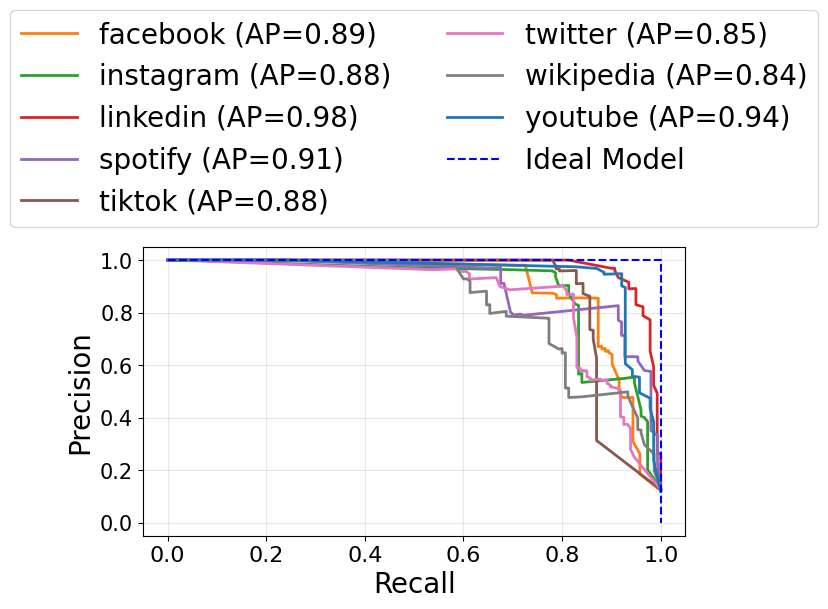

In [ ]:
# Binarize the labels (one-vs-rest)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

class_names = ['facebook', 'instagram', 'linkedin', 'spotify', 'tiktok', 'twitter', 'wikipedia', 'youtube']

# Custom color map provided by the user
color_map = {
    "youtube": "#1f77b4",
    "facebook": "#ff7f0e",
    "instagram": "#2ca02c",
    "linkedin": "#d62728",
    "spotify": "#9467bd",
    "tiktok": "#8c564b",
    "twitter": "#e377c2",
    "wikipedia": "#7f7f7f"
}

# Align class_names with the keys in the provided color_map for consistent ordering
ordered_colors = [color_map[name] for name in class_names]

# Ensure classes are numeric indices (0..N-1)
classes = np.arange(len(class_names))
y_true_bin = label_binarize(y_true, classes=classes)
n_classes = y_true_bin.shape[1]

# Plot PR curve per class
plt.figure(figsize=(7,3.75))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_scores[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_scores[:, i])
    plt.plot(recall, precision, lw=2, label=f"{class_names[i]} (AP={ap:.2f})", color=ordered_colors[i])

# Ideal model reference line (┐ shape)
plt.plot([0, 1, 1], [1, 1, 0], color="blue", linestyle="--", label="Ideal Model")

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),  # just above the plot
    fontsize=20,
    framealpha=0.8,
    fancybox=True,
    ncol=2
)


plt.rcParams.update({
    "font.size": 14,        # default text size
    "axes.titlesize": 20,   # title size
    "axes.labelsize": 20,   # x and y labels
    "xtick.labelsize": 16,  # x tick labels
    "ytick.labelsize": 16,  # y tick labels
})

plt.grid(alpha=0.3)
plt.savefig("pr_curve_RF_multimedia_apps.pdf", bbox_inches="tight")

plt.show()

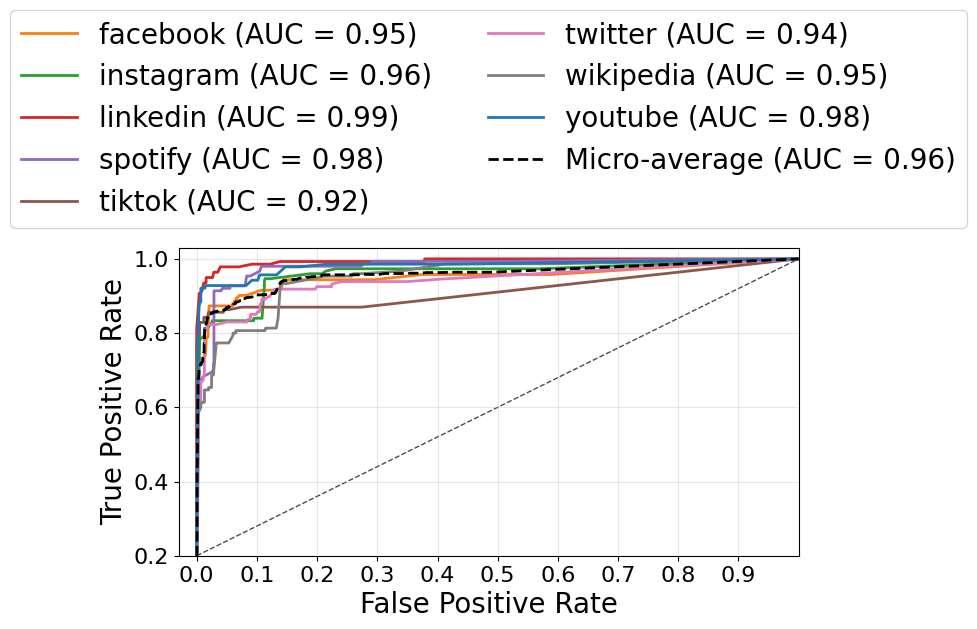

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

plt.figure(figsize=(8,4))

# Binarize labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=np.arange(len(class_numbers)))
n_classes = y_test_bin.shape[1]

class_names = ['facebook', 'instagram', 'linkedin', 'spotify', 'tiktok', 'twitter', 'wikipedia', 'youtube']

# Define the custom color map
color_map = {
    "youtube": "#1f77b4",
    "facebook": "#ff7f0e",
    "instagram": "#2ca02c",
    "linkedin": "#d62728",
    "spotify": "#9467bd",
    "tiktok": "#8c564b",
    "twitter": "#e377c2",
    "wikipedia": "#7f7f7f"
}

# Get prediction probabilities
y_score = model.predict_proba(X_test)

# Compute ROC curve and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot all ROC curves


# Diagonal line
plt.plot([0.0, 1], [0.2, 1.0], 'k--', lw=1, alpha=0.7, zorder=0)

# Add grid with minor ticks
# plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.grid(alpha=0.3)

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})", color=color_map[class_names[i]])

# Micro-average curve
plt.plot(fpr["micro"], tpr["micro"], color="#000000", linestyle="--",
         label=f"Micro-average (AUC = {roc_auc['micro']:.2f})", lw=2)


# Axis settings
plt.xlim([-0.03, 1])   # Only show FPR up to 0.4
plt.ylim([0.6, 1.03])  # Zoom into TPR between 0.6 and 1.0

# Minor ticks within reduced range
plt.xticks(np.arange(0, 1, 0.1))
plt.yticks(np.arange(0.2, 1.05, 0.2))

# Labels and legend
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
# Legend formatting (no border box)
plt.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),  # just above the plot
    fontsize=20,
    framealpha=0.8,
    fancybox=True,
    ncol=2
)


plt.rcParams.update({
    "font.size": 14,        # default text size
    "axes.titlesize": 20,   # title size
    "axes.labelsize": 20,   # x and y labels
    "xtick.labelsize": 16,  # x tick labels
    "ytick.labelsize": 15,  # y tick labels
})

# Save and show
plt.savefig("roc_curve_RF_multimedia_apps.pdf", bbox_inches="tight")
plt.show()

In [ ]:
np.save("y_test_res.npy", y_test_res)
np.save("y_pred.npy", y_pred)

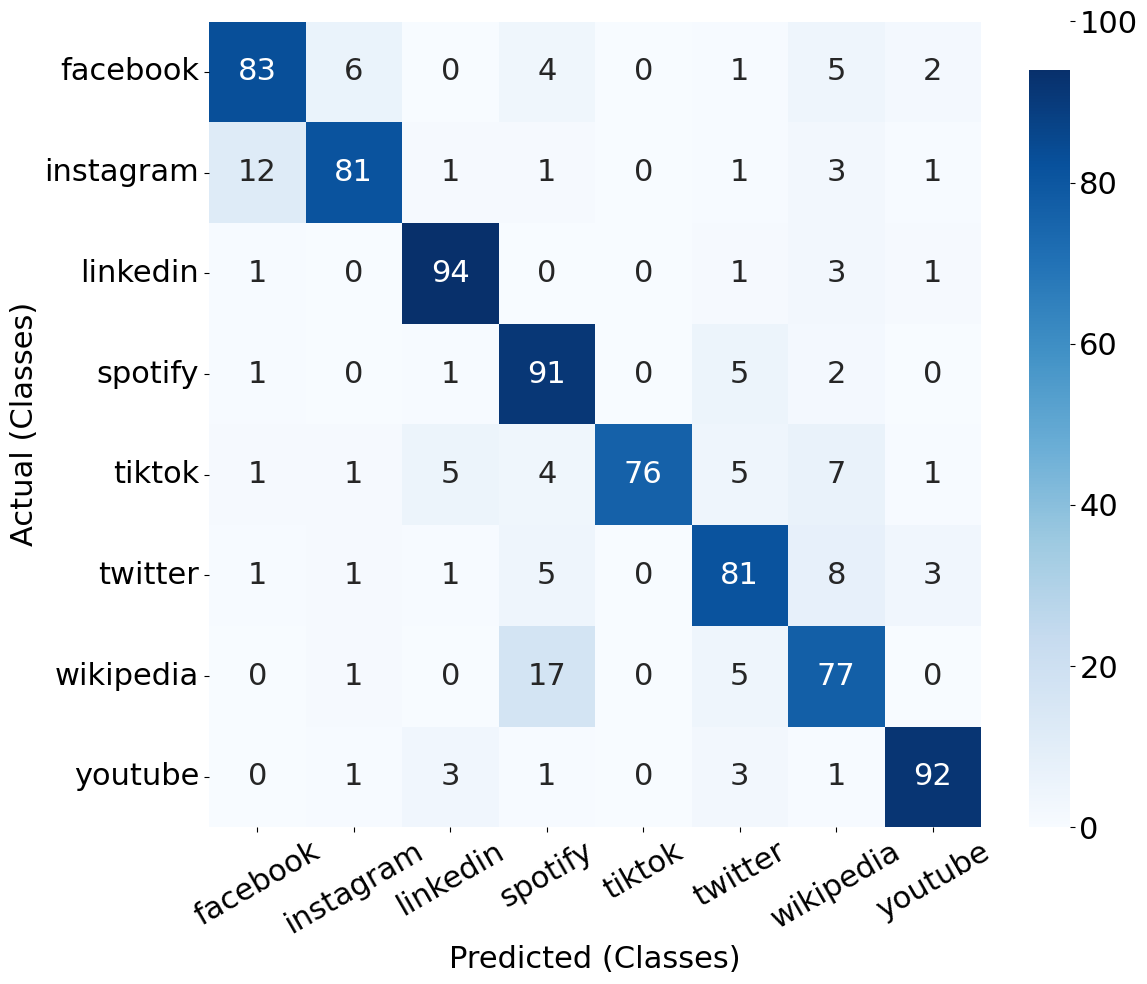

In [19]:
# conf_matrix = confusion_matrix(y_test, y_pred, normalize="true")
# print(df.columns)
# accuracy = class_report["accuracy"] * 100
# precision = class_report["weighted avg"]["precision"] * 100
# recall = class_report["weighted avg"]["recall"] * 100
# weighted_f1 = class_report["weighted avg"]["f1-score"] * 100
# macro_f1 = class_report["macro avg"]["f1-score"] * 100
# X = test_data.drop(columns=["Label"])
# y = test_data["Label"]

# labels = sorted(y.unique())

# # Call Plotting Functions
# plot_confusion_matrix(conf_matrix, labels, save_path="confusion_matrix.pdf")
# warnings.filterwarnings("ignore")

#-----------smote---------------------
# --- CONFUSION MATRIX FIXED ---
labels = np.unique(np.concatenate([y_test_res, y_pred]))  # include all classes
conf_matrix = confusion_matrix(y_test_res, y_pred, labels=labels, normalize="true")

# Classification metrics
accuracy = class_report["accuracy"] * 100
precision = class_report["weighted avg"]["precision"] * 100
recall = class_report["weighted avg"]["recall"] * 100
weighted_f1 = class_report["weighted avg"]["f1-score"] * 100
macro_f1 = class_report["macro avg"]["f1-score"] * 100

# Plot Confusion Matrix
plot_confusion_matrix(conf_matrix, labels, save_path="confusion_matrix.pdf")



### Save the model

In [ ]:
save_model(model, "multimedia_app_classification.pkl")